<a href="https://colab.research.google.com/github/miffylim2308/ADALL_github/blob/main/ADALL_Week4_Modelling_Evaluation_revised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**<font color='red'>dated 23.07.2026 9:16PM**

# ADALL Week 4 Practical: Modelling and Evaluation

**Module:** AI-driven Analytics with Large Language Models  
**Platform:** Google Colab  
**Class time:** 2 sessions × 130 minutes

This lab continues from Week 3.

Week 3 created files for manual GitHub upload. Week 4 loads those files from GitHub and uses them for modelling and evaluation.

```text
Week 3 files on GitHub → load train/test files → preprocess → train models → compare → evaluate → explain judgement
```

### Session timing overview

| Session | Target time | Main outcome |
|---|---:|---|
| Session 1 | 130 minutes | Load Week 3 files from GitHub and train comparable models |
| Session 2 | 130 minutes | Evaluate the selected model visually and write a justified judgement |

### Important rule for this lab

Do not depend on saved encoders or saved model files. Week 4 should rebuild the preprocessing and models using the CSV files produced in Week 3.

---
# Session 1: Load Week 3 files and train comparable models

**Target duration:** 130 minutes

By the end of Session 1, you should have trained several models using the same Week 3 train/test split.

## Chapter 1. Setup and load libraries

**Suggested time:** 8 minutes

Run this first. The install line is included because XGBoost may not already be available in a fresh Colab runtime.

In [ ]:
!pip -q install xgboost

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import ShuffleSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

RANDOM_STATE = 42

print('Setup complete')

Setup complete


## Chapter 2. Load Week 3 files from GitHub

**Suggested time:** 20 minutes

In Week 3, you created files and uploaded them manually to GitHub.

For Week 4, load these four files from your GitHub raw folder:

| File | Purpose |
|---|---|
| `train_features.csv` | Training predictors |
| `test_features.csv` | Test predictors |
| `train_target.csv` | Training target |
| `test_target.csv` | Test target |

Change `GITHUB_BASE_URL` so it points to your own GitHub raw folder.

Example folder pattern:

```text
https://raw.githubusercontent.com/YOUR_USERNAME/YOUR_REPO/main/week3_github_upload/
```

If you are testing locally in Colab, you may replace `GITHUB_BASE_URL` with an empty string and upload the four CSV files into Colab.

In [ ]:
GITHUB_BASE_URL = 'https://raw.githubusercontent.com/zawhtetwai/ADALL_GitHub/main/week3_github_upload/'

X_train = pd.read_csv(GITHUB_BASE_URL + 'train_features.csv')
X_test = pd.read_csv(GITHUB_BASE_URL + 'test_features.csv')

y_train_df = pd.read_csv(GITHUB_BASE_URL + 'train_target.csv')
y_test_df = pd.read_csv(GITHUB_BASE_URL + 'test_target.csv')

y_train = y_train_df.iloc[:, 0]
y_test = y_test_df.iloc[:, 0]

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)
print('y_train:', y_train.shape)
print('y_test :', y_test.shape)

X_train.head()


X_train: (800, 9)
X_test : (200, 9)
y_train: (800,)
y_test : (200,)


,Brand,Model,CPU,GPU,RAM_GB,Storage_GB,Touchscreen,Weight_kg,Screen_Size_inch
0,Acer,TravelMate P6,Intel Core Ultra 7 15500H,NVIDIA RTX 4070,32,4096,True,2.34,15.6
1,HP,Pavilion 15,Intel i5-14600H,NVIDIA RTX 4050,32,1024,True,2.34,16.0
2,Lenovo,Legion 5,Intel i7-14700H,NVIDIA RTX 4060,64,512,False,1.57,15.6
3,HP,Envy 13,Intel i9-14900HK,NVIDIA RTX 4070,64,256,True,2.97,17.3
4,Microsoft,Surface Laptop 5,Intel i7-14700H,NVIDIA RTX 4060,16,512,True,3.06,18.4


### Local Colab alternative

Use this only if you have not uploaded the files to GitHub yet.

1. Upload the four CSV files into Colab.
2. Change the previous code cell to:

```python
GITHUB_BASE_URL = ''
```

Then the same `pd.read_csv()` lines will load the local files.

Do not use both methods at the same time.

## Chapter 3. Confirm the modelling task

**Suggested time:** 8 minutes

The Week 3 split should still be used here.

| Item | Decision |
|---|---|
| Task type | Regression |
| Target | Laptop price in SGD |
| Main metric | MAE, because it is easy to explain in dollars |

###<font color='blue'>Why not just vibe code with Gemini? </font>

Lets ask Gemini to generate code:

Generate on a new cell with the prompt "perform modelling with X_train, X_test, y_train, and y_test"

### Combined Preprocessing and Modelling

This section consolidates the definition of numeric and categorical columns, the `ColumnTransformer` preprocessor, and the training and evaluation of multiple regression models (Decision Tree, Random Forest, XGBoost) using pipelines and cross-validation.

In [ ]:
#Generate code with Gemini for this cell

###Gemini:

Was there any error? Was there any missing steps?
Did it encode? Was there pipeline and cross-validation?

###<font color='blue'>Lets try with OpenAI </font>
Refer to week3 material, do you know what cells you need to copy and paste over?

In [ ]:
#Copy and paste the code to query with OpenAI API.
#Instantiate an OpenAI Client
from google.colab import userdata
from openai import OpenAI

# Load key from Google Colab Secrets
api_key = userdata.get('OPENAI_API_KEY')

client = OpenAI(
    api_key=api_key,
)

In [ ]:
# -----------------------------
# Note: The following is the solution.
# Do try it out yourselves first.
# -----------------------------

RUN_API_CELLS = True
OPENAI_MODEL = 'gpt-5.4-nano'
client = None

# Only use this section if your tutor has asked you to call the API from Colab.
# You must first save OPENAI_API_KEY in Colab Secrets.

if RUN_API_CELLS == True:
    from google.colab import userdata
    from openai import OpenAI

    api_key = userdata.get('OPENAI_API_KEY')
    client = OpenAI(api_key=api_key)
    print('OpenAI client is ready.')
else:
    print('Manual chatbot mode. Copy the prompts when they appear.')

OpenAI client is ready.


In [ ]:
quality_prompt2 = f"""
Generate simple and executable python code to generate ColumnTransformer (use "passthrough" for numeric columns, use "onehot encoding" for categorical columns) preprocessor,
and the training and evaluation of multiple regression models (Decision Tree, Random Forest, XGBoost) using pipelines and cross-validation.
Metrics of the models evaluation are MAE, RMSE and R2.
Show th compparison of the performance of the models.
"""

if client is not None:
    response2 = client.responses.create(
        model=OPENAI_MODEL,
        input=quality_prompt2
    )
    print('\nLLM response:')
    print(response2.output_text)
else:
    print('\nNo API response because client is not connected. Copy the prompt above into your chatbot.')



LLM response:
```python
# Simple, executable example: ColumnTransformer + pipelines + CV for
# DecisionTreeRegressor, RandomForestRegressor, XGBoost
#
# Assumptions:
# - You have a pandas DataFrame `df`
# - `target_col` is the name of the target column
#
# Install (if needed):
# pip install scikit-learn xgboost pandas numpy

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor


# -----------------------------
# 1) Load / prepare your data
# -----------------------------
# df = pd.read_csv("your_file.csv")
# target_col = "target"
#
# Example placeholder:
# df = pd.DataFrame(...)
# target_col


=== Cross-validated model comparison ===
        Model  MAE (mean)  MAE (std)  RMSE (mean)  RMSE (std)  R2 (mean)  R2 (std)
      XGBoost    2.870073   0.163715     3.626906    0.176042   0.932053  0.008520
Random Forest    3.050135   0.263923     3.870803    0.233140   0.922767  0.009081
Decision Tree    4.241107   0.263246     5.342974    0.227724   0.852746  0.016511


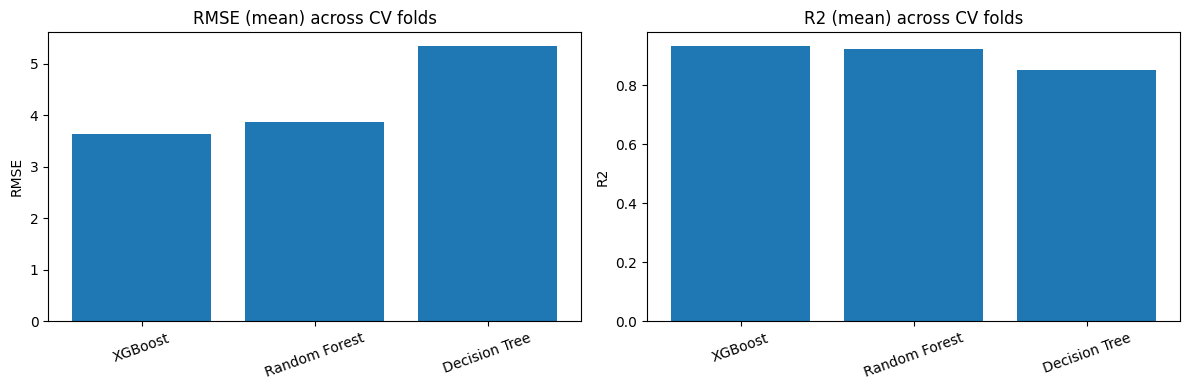

In [ ]:
#Paste the OpenAI response here

# Simple, executable example: ColumnTransformer + pipelines + CV for
# DecisionTreeRegressor, RandomForestRegressor, XGBoost
#
# Assumptions:
# - You have a pandas DataFrame `df`
# - `target_col` is the name of the target column
#
# Install (if needed):
# pip install scikit-learn xgboost pandas numpy

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor


# -----------------------------
# 1) Load / prepare your data
# -----------------------------
# df = pd.read_csv("your_file.csv")
# target_col = "target"
#
# Example placeholder:
# df = pd.DataFrame(...)
# target_col = "target"

# ---- CHANGE THESE TWO LINES FOR YOUR DATA ----
target_col = "target"  # <-- set your target column name
# df = ...              # <-- set your dataframe
# -----------------------------------------------

X = df.drop(columns=[target_col])
y = df[target_col].values

# Identify column types
categorical_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
numeric_cols = [c for c in X.columns if c not in categorical_cols]

# -----------------------------
# 2) Preprocessor (CT)
# -----------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ],
    remainder="drop"
)

# -----------------------------
# 3) Models & pipelines
# -----------------------------
models = {
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        objective="reg:squarederror",
        n_jobs=-1,
    ),
}

# -----------------------------
# 4) Metrics (MAE, RMSE, R2)
# -----------------------------
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

scoring = {
    "MAE": make_scorer(mean_absolute_error, greater_is_better=False),
    "RMSE": make_scorer(rmse, greater_is_better=False),
    "R2": make_scorer(r2_score, greater_is_better=True),
}

# Note: MAE and RMSE are negated because scikit-learn expects "higher is better"
# when greater_is_better=False. We'll convert back after scoring.

# -----------------------------
# 5) Cross-validation training & evaluation
# -----------------------------
cv = KFold(n_splits=5, shuffle=True, random_state=42)

results = []
for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", model)
    ])

    cv_out = cross_validate(
        pipe,
        X, y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    mae_scores = -cv_out["test_MAE"]   # convert back to positive MAE
    rmse_scores = -cv_out["test_RMSE"] # convert back to positive RMSE
    r2_scores = cv_out["test_R2"]

    results.append({
        "Model": name,
        "MAE (mean)": mae_scores.mean(),
        "MAE (std)": mae_scores.std(),
        "RMSE (mean)": rmse_scores.mean(),
        "RMSE (std)": rmse_scores.std(),
        "R2 (mean)": r2_scores.mean(),
        "R2 (std)": r2_scores.std(),
    })

df_results = pd.DataFrame(results).sort_values("RMSE (mean)")
print("\n=== Cross-validated model comparison ===")
print(df_results.to_string(index=False))

# -----------------------------
# 6) Simple visual comparison (optional)
# -----------------------------
try:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    # RMSE
    axes[0].bar(df_results["Model"], df_results["RMSE (mean)"])
    axes[0].set_title("RMSE (mean) across CV folds")
    axes[0].set_ylabel("RMSE")
    axes[0].tick_params(axis="x", rotation=20)

    # R2
    axes[1].bar(df_results["Model"], df_results["R2 (mean)"])
    axes[1].set_title("R2 (mean) across CV folds")
    axes[1].set_ylabel("R2")
    axes[1].tick_params(axis="x", rotation=20)

    plt.tight_layout()
    plt.show()
except Exception as e:
    print("\n(Plot skipped due to error):", e)


OpenAI:
Try to run the code given. Was there any error? Was there any missing steps? Did it encode? Did it assume it to be classification or regression modelling problem? Was there pipeline and cross-validation?

###<font color='blue'> Lets continue with manual modelling task to know what is a good modelling code is first </font>
with X_train, X_test, y_train, and y_test

In [ ]:
print('Training columns:')
print(X_train.columns.tolist())

print('Target summary:')
print(y_train.describe())

Training columns:
['Brand', 'Model', 'CPU', 'GPU', 'RAM_GB', 'Storage_GB', 'Touchscreen', 'Weight_kg', 'Screen_Size_inch']
Target summary:
count     800.000000
mean     3083.203425
std       790.558066
min      1594.700000
25%      2448.237500
50%      3032.130000
75%      3679.160000
max      4984.620000
Name: Price_SGD, dtype: float64


## Chapter 4. Identify numeric and categorical columns

**Suggested time:** 10 minutes

The model cannot use text columns directly. We will one-hot encode categorical columns and pass numeric columns through.

In [ ]:
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

print('Numeric columns:')
print(num_cols)

print('Categorical columns:')
print(cat_cols)

Numeric columns:
['RAM_GB', 'Storage_GB', 'Weight_kg', 'Screen_Size_inch']
Categorical columns:
['Brand', 'Model', 'CPU', 'GPU']


## Chapter 5. Build one shared preprocessing step

**Suggested time:** 12 minutes

All models should use the same preprocessing. This makes the comparison fairer.

First we need to replace all string into numerical numbers.

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

preprocessor

ColumnTransformer(transformers=[('num', 'passthrough',
                                 Index(['RAM_GB', 'Storage_GB', 'Weight_kg', 'Screen_Size_inch'], dtype='object')),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 Index(['Brand', 'CPU', 'GPU', 'Model', 'Touchscreen'], dtype='object'))])

## Chapter 6. Train a Decision Tree baseline

**Suggested time:** 20 minutes

Start with a simple model first. This gives you a baseline for comparison.

In [ ]:
dt_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(
        max_depth=5, # max depth of the tree, the higher the number, the more complex the tree, too complex may mean the model just memorizes the training data (aka overfitting)
        random_state=RANDOM_STATE
        ))
])

dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

dt_mae = mean_absolute_error(y_test, dt_pred)
dt_rmse = mean_squared_error(y_test, dt_pred) ** 0.5
dt_r2 = r2_score(y_test, dt_pred)

print('Decision Tree MAE :', round(dt_mae, 2))
print('Decision Tree RMSE:', round(dt_rmse, 2))
print('Decision Tree R2  :', round(dt_r2, 3))

Decision Tree MAE : 200.53
Decision Tree RMSE: 254.18
Decision Tree R2  : 0.882


## Chapter 7. Train a Random Forest model

**Suggested time:** 20 minutes

Random Forest improves on a single Decision Tree by combining many trees looking different parts of the dataset.

In [ ]:
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=150, # number of trees in the forest
        random_state=RANDOM_STATE,
        n_jobs=-1
        ))
])

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = mean_squared_error(y_test, rf_pred) ** 0.5
rf_r2 = r2_score(y_test, rf_pred)

print('Random Forest MAE :', round(rf_mae, 2))
print('Random Forest RMSE:', round(rf_rmse, 2))
print('Random Forest R2  :', round(rf_r2, 3))

Random Forest MAE : 80.66
Random Forest RMSE: 105.44
Random Forest R2  : 0.98


## Chapter 8. Train an XGBoost model

**Suggested time:** 22 minutes

XGBoost use multiple decision trees in sequence, building one after another to focus on mistakes made by earlier trees.

It can perform well, but it is also easier to over-tune. In this beginner lab, keep the settings simple.

In [ ]:
xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        n_estimators=150, # number of trees
        max_depth=4, # max depth of each tree
        learning_rate=0.08, # how carefully, and thus slowly the model tries to improve
        subsample=0.9, # how similar the dataset in rows should be for each tree
        colsample_bytree=0.9, # how similar the dataset in columns should be for each tree
        random_state=RANDOM_STATE,
        objective='reg:squarederror',
        n_jobs=1
    ))
])

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = mean_squared_error(y_test, xgb_pred) ** 0.5
xgb_r2 = r2_score(y_test, xgb_pred)

print('XGBoost MAE :', round(xgb_mae, 2))
print('XGBoost RMSE:', round(xgb_rmse, 2))
print('XGBoost R2  :', round(xgb_r2, 3))

XGBoost MAE : 57.6
XGBoost RMSE: 73.05
XGBoost R2  : 0.99


## Chapter 9. Compare model test results

**Suggested time:** 10 minutes

Lower MAE and RMSE are better. Higher R2 is better.

Do not choose the final model using only one number. The plots in Session 2 still matter.

In [ ]:
test_results = pd.DataFrame({
    'model': ['Decision Tree', 'Random Forest', 'XGBoost'],
    'test_mae': [dt_mae, rf_mae, xgb_mae],
    'test_rmse': [dt_rmse, rf_rmse, xgb_rmse],
    'test_r2': [dt_r2, rf_r2, xgb_r2]
})

test_results = test_results.sort_values('test_mae')
test_results

,model,test_mae,test_rmse,test_r2
2,XGBoost,57.601006,73.047077,0.990281
1,Random Forest,80.660877,105.436849,0.979752
0,Decision Tree,200.527916,254.180953,0.882326


## Chapter 10. Cross-validation check on the training data

**Suggested time:** 15 minutes

The test results above are useful, but they come from one test set only.

Cross-validation checks model performance using repeated train/validation splits inside the training data.

In [ ]:
cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=RANDOM_STATE)

dt_cv_scores = cross_val_score(dt_model, X_train, y_train, cv=cv, scoring='neg_mean_absolute_error')
rf_cv_scores = cross_val_score(rf_model, X_train, y_train, cv=cv, scoring='neg_mean_absolute_error')
xgb_cv_scores = cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring='neg_mean_absolute_error')

cv_results = pd.DataFrame({
    'model': ['Decision Tree', 'Random Forest', 'XGBoost'],
    'cv_mae': [-dt_cv_scores.mean(), -rf_cv_scores.mean(), -xgb_cv_scores.mean()],
    'cv_mae_std': [dt_cv_scores.std(), rf_cv_scores.std(), xgb_cv_scores.std()]

})

cv_results = cv_results.sort_values('cv_mae')
cv_results

# This cell compares three models using 5 rounds of cross-validation.
# Each round trains on 80% of X_train and tests on the remaining 20%.
# cross_val_score returns negative MAE, so we use the negative mean to show normal MAE values.
# cv_mae shows the average error for each model across the 5 rounds.
# cv_mae_std shows how much the error changes across the 5 rounds.
# Sorting by cv_mae puts the model with the lowest average error at the top.

,model,cv_mae,cv_mae_std
2,XGBoost,63.218632,2.354819
1,Random Forest,100.084831,3.163689
0,Decision Tree,224.565378,3.583386


## Chapter 11. Session 1 checkpoint

**Suggested time:** 5 minutes

Write your current decision:

```text
Based on the Week 3 train/test files, the best model so far is ______.
My evidence is ______.
Before I make the final recommendation, I still need to check plots and error patterns.
```

###<font color='blue'>Why is a better prompt for vibe code with OpenAI? </font>


In [ ]:
#Paste the OpenAI response here

However, you may be experiencing long runtime for a simple dataset. This is because the OpenAI may have provided a detailed (but may not be necessary for a simple dataset) model hyperparameter tuning, using GridSearchCV.

---
# Session 2: Model diagnosis, error investigation, and final judgement

**Target duration:** 130 minutes

Session 2 is not only about getting a score. A score tells you **how wrong** the model is on average, but it does not tell you **where**, **why**, or **whether the model is safe enough to recommend**.

By the end of Session 2, you should be able to:

1. select a model using cross-validation evidence,
2. compare the selected model against a simple baseline,
3. inspect large errors and error direction,
4. check whether errors are worse for some price bands or brands,
5. use simple feature importance evidence,
6. write a careful final model judgement.

**Main idea:** A model is not automatically useful just because it has the best score.

## Chapter 12. Select the model for final evaluation

**Suggested time:** 10 minutes

Use the CV table first. If two models are very close, choose the simpler model.

### Discussion prompt

Before running the next cell, answer this:

```text
Which model do you expect to be selected, and why?
```

Do not use the test set to choose the model. The test set should be used only after the model has been selected.

In [ ]:
best_model_name = cv_results.iloc[0]['model']

best_model = dt_model
best_pred = dt_pred

if best_model_name == 'Random Forest':
    best_model = rf_model
    best_pred = rf_pred

if best_model_name == 'XGBoost':
    best_model = xgb_model
    best_pred = xgb_pred

print('Selected model:', best_model_name)
cv_results

## Chapter 13. Compare against a simple mean-price baseline

**Suggested time:** 15 minutes

A model should beat a very simple baseline. For regression, one simple baseline is:

```text
Always predict the average training price.
```

This is a useful sanity check. If the machine learning model is only slightly better than this, the model may not be worth deploying.

In [ ]:
from sklearn.dummy import DummyRegressor

mean_baseline = DummyRegressor(strategy='mean')
mean_baseline.fit(X_train, y_train)
mean_pred = mean_baseline.predict(X_test)

baseline_mae = mean_absolute_error(y_test, mean_pred)
baseline_rmse = mean_squared_error(y_test, mean_pred) ** 0.5
baseline_r2 = r2_score(y_test, mean_pred)

print('Mean-price baseline')
print('MAE :', round(baseline_mae, 2))
print('RMSE:', round(baseline_rmse, 2))
print('R2  :', round(baseline_r2, 3))

# This cell creates a 'blindly-guess' model.
# DummyRegressor(strategy='mean') always predicts the average laptop price from the training data, regardless of details of input provided.
# This gives us a very basic benchmark before using real machine learning models.
# If our trained models cannot beat this baseline, they are not useful yet.
# MAE, RMSE, and R2 show how well this simple baseline performs on the test set.

### Try it yourself

Explain the baseline in one sentence:

```text
The baseline predicts ______ for every laptop, so it is useful because ______.
```

## Chapter 14. Evaluate the selected model on the test set

**Suggested time:** 15 minutes

The test set is the final check after model comparison.

MAE is easiest to explain to a non-technical user. RMSE gives more penalty to large errors. R2 gives a general fit score, but it can be less direct for business users.

In [ ]:
test_mae = mean_absolute_error(y_test, best_pred)
test_rmse = mean_squared_error(y_test, best_pred) ** 0.5
test_r2 = r2_score(y_test, best_pred)

comparison_to_baseline = pd.DataFrame({
    'model': ['Mean-price baseline', best_model_name],
    'MAE': [baseline_mae, test_mae],
    'RMSE': [baseline_rmse, test_rmse],
    'R2': [baseline_r2, test_r2]
})

comparison_to_baseline['MAE_improvement_vs_baseline'] = baseline_mae - comparison_to_baseline['MAE']
comparison_to_baseline['MAE_improvement_percent'] = (comparison_to_baseline['MAE_improvement_vs_baseline'] / baseline_mae) * 100

comparison_to_baseline.round(3)

# This cell compares the best trained model against the simple mean-price baseline.
# test_mae, test_rmse, and test_r2 measure the best model's performance on the test set.
# comparison_to_baseline puts the baseline and best model results in one table.
# MAE_improvement_vs_baseline shows how much lower the MAE is compared with the baseline.
# MAE_improvement_percent shows the improvement as a percentage.
# A positive improvement means the best model predicts better than simply using the average price.

### Student checkpoint

Write one sentence:

```text
Compared with the mean-price baseline, the selected model reduces MAE by about ______%, so ______.
```

This forces you to judge whether the improvement is meaningful, not only whether it is technically better.

## Chapter 15. Create an error table with error direction

**Suggested time:** 15 minutes

An error table helps you see where the model is wrong.

Error direction matters:

| Error direction | Meaning |
|---|---|
| positive error | model predicted too high |
| negative error | model predicted too low |
| near zero error | model prediction was close |

For laptop pricing, over-prediction and under-prediction may lead to different business problems.

In [ ]:
error_df = X_test.copy()
error_df['actual_price'] = y_test.values
error_df['predicted_price'] = best_pred
error_df['error'] = error_df['predicted_price'] - error_df['actual_price']
error_df['absolute_error'] = error_df['error'].abs()
error_df['absolute_percentage_error'] = (error_df['absolute_error'] / error_df['actual_price']) * 100

error_df['error_direction'] = np.where(
    error_df['error'] > 0,
    'over-predicted',
    np.where(error_df['error'] < 0, 'under-predicted', 'exact')
)

error_df.sort_values('absolute_error', ascending=False).head(10)

# This cell creates a detailed error table for the best model.
# actual_price stores the true laptop price from y_test.
# predicted_price stores the model's predicted price.
# error shows whether the prediction is too high or too low.
# absolute_error shows the size of the mistake, ignoring direction.
# absolute_percentage_error shows the mistake as a percentage of the actual price.
# error_direction labels each prediction as over-predicted, under-predicted, or exact.
# Sorting by absolute_error shows the largest mistakes first.

### Try it yourself

Look at the top 10 largest errors.

Write down two possible reasons why these cases are difficult:

```text
Reason 1: ______
Reason 2: ______
```

Do not claim the reason is confirmed unless the table clearly supports it.

## Chapter 16. Actual vs predicted scatter plot

**Suggested time:** 15 minutes

A good model should have points close to the diagonal line.

Use this plot to check whether the model becomes weaker for cheaper or more expensive laptops.

In [ ]:
plt.figure(figsize=(8, 8))
plt.scatter(error_df['actual_price'], error_df['predicted_price'], alpha=0.7)

min_value = min(error_df['actual_price'].min(), error_df['predicted_price'].min())
max_value = max(error_df['actual_price'].max(), error_df['predicted_price'].max())
plt.plot([min_value, max_value], [min_value, max_value])

plt.xlabel('Actual Price SGD')
plt.ylabel('Predicted Price SGD')
plt.title('Actual vs Predicted Price')
plt.show()



### Visual reading guide

Use this table when reading the graph:

| Pattern seen | Possible meaning |
|---|---|
| points close to diagonal line | prediction is close |
| points far above line | model predicts too high |
| points far below line | model predicts too low |
| wider spread at high prices | model struggles more with expensive laptops |

This is a visual judgement. It should be supported later with tables.

## Chapter 17. Residual plot and bias check

**Suggested time:** 15 minutes

A residual plot shows whether the model tends to over-predict or under-predict at different price levels.

A good residual plot does not need to be perfect. However, you should watch for a clear pattern.

In [ ]:
plt.figure(figsize=(9, 5))
plt.scatter(error_df['actual_price'], error_df['error'], alpha=0.7)
plt.axhline(0)
plt.xlabel('Actual Price SGD')
plt.ylabel('Prediction Error')
plt.title('Prediction Error by Actual Price')
plt.show()

In [ ]:
error_direction_summary = error_df['error_direction'].value_counts().reset_index()
error_direction_summary.columns = ['error_direction', 'count']
error_direction_summary['percent'] = error_direction_summary['count'] / len(error_df) * 100
error_direction_summary.round(2)

### Try it yourself

Answer this based on the table and plot:

```text
The model mostly over-predicts / under-predicts / is balanced. My evidence is ______.
```

## Chapter 18. Error by price band

**Suggested time:** 20 minutes

Average error can hide weakness for cheap or expensive laptops.

Here, we split the test records into price bands and compare MAE and MAPE.

MAE tells you the error in SGD. MAPE tells you the error as a percentage of the actual price.

MAE= Mean Absolute Error

MAPE = Mean Absolute Percentage Error

In [ ]:
error_df['price_band'] = pd.qcut(
    error_df['actual_price'],
    q=4,
    labels=['lowest price band', 'lower-middle price band', 'upper-middle price band', 'highest price band']
)

price_band_error = error_df.groupby('price_band', observed=True).agg(
    count=('absolute_error', 'size'),
    mean_actual_price=('actual_price', 'mean'),
    mae=('absolute_error', 'mean'),
    mape=('absolute_percentage_error', 'mean'),
    median_absolute_error=('absolute_error', 'median')
).reset_index()

price_band_error.round(2)

# This cell checks model error across different price bands.
# pd.qcut() splits laptops into 4 groups based on actual price.
# Each price band should have roughly similar number of records.
# groupby() calculates error statistics for each price band.
# mae shows the average dollar error in each band.
# mape shows the average percentage error in each band.
# This helps us see whether the model performs better or worse for cheaper or more expensive laptops.

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(price_band_error['price_band'], price_band_error['mae'])
plt.xticks(rotation=20, ha='right')
plt.ylabel('MAE')
plt.title('MAE by Price Band')
plt.show()

### Discussion prompt

A model may have higher MAE for expensive laptops because the prices are larger. That does not always mean the model is unfair or unusable.

Check both MAE and MAPE before judging.

```text
The model is weakest for ______ because ______.
```

## Chapter 19. Error by brand

**Suggested time:** 15 minutes

Group-level error helps you check whether the model is much worse for some brands.

This cell assumes that `Brand` is still one of the predictor columns from Week 3.

In [ ]:
if 'Brand' in error_df.columns:
    brand_error = error_df.groupby('Brand').agg(
        count=('absolute_error', 'size'),
        mae=('absolute_error', 'mean'),
        mape=('absolute_percentage_error', 'mean'),
        mean_actual_price=('actual_price', 'mean')
    )

    brand_error = brand_error.sort_values('mae', ascending=False)
    display(brand_error.head(10).round(2))
else:
    print('Brand column not found in error_df. Skip this section or replace Brand with another group column.')

In [ ]:
if 'Brand' in error_df.columns:
    brand_error_plot = brand_error[brand_error['count'] >= 3]
    brand_error_plot = brand_error_plot.sort_values('mae', ascending=False).head(12)

    plt.figure(figsize=(12, 5))
    plt.bar(brand_error_plot.index, brand_error_plot['mae'])
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('MAE by brand')
    plt.title('Largest average errors by brand')
    plt.show()

# This cell plots the brands where the model has the largest average errors.
# It only runs if the Brand column exists in error_df.
# brand_error_plot keeps brands with at least 3 test records, so the result is less affected by one unusual laptop.
# The brands are sorted by MAE, with the largest errors shown first.
# The bar chart helps us see which brands the model may be struggling with.

### Caution

Do not overclaim from small groups.

A brand with only 1 or 2 records may look very bad because of one unusual laptop. That is why the chart filters to brands with at least 3 test records.

## Chapter 20. Check feature importance using permutation importance

**Suggested time:** 20 minutes

Feature importance helps you explain what the model depends on.

Here we use permutation importance. The idea is simple:

```text
Shuffle one column. If the model becomes much worse, that column was important.
```

This is more useful than guessing based only on your own intuition.

In [ ]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring='neg_mean_absolute_error'
)

importance_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std
})

importance_df = importance_df.sort_values('importance_mean', ascending=False)
importance_df.head(10).round(3)

In [ ]:
importance_plot = importance_df.head(10).sort_values('importance_mean')

plt.figure(figsize=(9, 5))
plt.barh(importance_plot['feature'], importance_plot['importance_mean'])
plt.xlabel('Increase in MAE after shuffling feature')
plt.title('Top 10 Permutation Importance Features')
plt.show()

### Try it yourself

Write one careful sentence:

```text
The model seems to rely most on ______, but this does not prove that ______ causes the price.
```

Feature importance is model evidence, not causal proof.

## Chapter 21. Prepare evidence for LLM-assisted interpretation

**Suggested time:** 15 minutes

Do not send the full dataset to the LLM. Send a small evidence summary and ask for help turning the evidence into a clear judgement.

The LLM should help with wording. It should not invent results.

In [ ]:
largest_errors = error_df[['actual_price', 'predicted_price', 'error', 'absolute_error', 'absolute_percentage_error', 'error_direction']]
largest_errors = largest_errors.sort_values('absolute_error', ascending=False).head(5)

top_features = importance_df.head(5)

brand_section = 'Brand column not available.'
if 'Brand' in error_df.columns:
    brand_section = brand_error.head(5).round(2).to_string()

evidence_text = f"""
Task: Predict laptop price in SGD.
Selected model: {best_model_name}

Comparison against mean-price baseline:
{comparison_to_baseline.round(3).to_string(index=False)}

Selected model test performance:
Test MAE: {test_mae:.2f}
Test RMSE: {test_rmse:.2f}
Test R2: {test_r2:.3f}

Error direction summary:
{error_direction_summary.round(2).to_string(index=False)}

Error by price band:
{price_band_error.round(2).to_string(index=False)}

Top 5 brands with largest MAE:
{brand_section}

Top 5 permutation importance features:
{top_features.round(3).to_string(index=False)}

Top 5 largest individual errors:
{largest_errors.round(2).to_string(index=False)}
"""

llm_prompt = f"""
You are helping a beginner data analytics student.
Use only the evidence below to write a short model evaluation judgement.
Do not invent causes.
Do not overclaim.
Mention:
1. whether the model beats the simple baseline,
2. one strength,
3. one weakness,
4. one caution about the evidence,
5. one sensible next step.

Evidence:
{evidence_text}
"""

print(llm_prompt)

## Chapter 22. Final model judgement

**Suggested time:** 15 minutes

Write your final answer in this structure:

```text
The selected model is ______.

Compared with the mean-price baseline, it ______.

The test MAE means that ______.

The visual checks show that ______.

The error band / brand analysis shows that ______.

The feature importance check suggests that the model relies on ______.

However, I should be careful because ______.

Therefore, I would / would not recommend using this model for ______.

A sensible next step is ______.
```

### Session 2 checkpoint

You should now have:

1. one selected model,
2. one baseline comparison,
3. test evaluation scores,
4. at least two visual checks,
5. an error direction summary,
6. an error by price band table,
7. a group-level error check,
8. a permutation importance check,
9. one evidence-based judgement paragraph.

# A4. Optional Reading: Cross-validation, holdout, and model judgement

Cross-validation helps you compare models using the training data. The holdout test set gives a final check after you have selected a model.

The common beginner mistake is using the test set too early. If you keep choosing models based on test results, the test set stops being a fair final check.

# A5. Optional Reading: Why visual evaluation matters

A single score can hide where the model is weak. Visual checks help you see patterns such as large errors for expensive items, systematic over-prediction, systematic under-prediction, or weaker performance for some brands or groups.

# A6. Optional Reading: Feature importance is not causal proof

Feature importance shows which columns the model uses for prediction. It does not prove that changing that column will cause the price to change.

For example, a feature can be important because it is a proxy for another hidden factor.

# Additional Practice

Use the same notebook structure with another regression dataset. Change only the GitHub raw folder, target meaning, columns used, and final written judgement.